# Point processes and event modelling

Events arrive in time -- tweets, trades, earthquakes, neuron spikes, server requests, defaults -- and modelling
their pattern is a discipline of its own: the theory of point processes. We work through it,
grounded in geotagged UK tweets. We build from the Poisson process and conjugate Bayesian rate estimation
through time-varying (inhomogeneous) intensity, renewal processes and the hazard function, overdispersion and
the negative binomial, the self-exciting Hawkes process (simulated, fit by maximum likelihood, and validated
by the time-rescaling theorem), mutually-exciting multivariate Hawkes, change-point detection, and Bayesian
model comparison -- exercising mixle's Poisson/Gamma conjugacy, hierarchical pooling, and the negative
binomial, alongside the estimation machinery the richer models need. Plotting is confined to a small helper so
the code is about models.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import kstest, expon, chi2
from mixle.ppl import Poisson, Gamma, NegativeBinomial
rng = np.random.RandomState(0)
def panel(ncol=1, w=5.0, h=3.0):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
df = pd.read_csv('../../data/tweets/geo_tweet_small.csv').dropna(subset=['Longitude', 'Latitude', 'Date', 'Hour'])
df['hh'] = df['Hour'].astype(str).str.slice(0, 2).astype(int)
def region(d, la0, la1, lo0, lo1): return d[(d.Latitude > la0) & (d.Latitude < la1) & (d.Longitude > lo0) & (d.Longitude < lo1)]
def hourly(d):
    hc = d.groupby(['Date', 'hh']).size().reset_index(name='n'); return {h: list(g['n'].astype(float)) for h, g in hc.groupby('hh')}
london = hourly(region(df, 51.2, 51.7, -0.5, 0.3))
print('London: %d days of data; counts per (day,hour) drive the rate models, simulated event streams the self-exciting ones' % len(set(region(df, 51.2, 51.7, -0.5, 0.3).Date)))

London: 8 days of data; counts per (day,hour) drive the rate models, simulated event streams the self-exciting ones


## 1. The Poisson process and conjugate rate estimation

The Poisson process is the baseline model of "completely random" arrivals: events in disjoint intervals are
independent, the count in an interval of length $\tau$ is Poisson($\lambda\tau$), and inter-arrival gaps are
exponential. For a rate from repeated counts, a Gamma$(a,b)$ prior is conjugate to the Poisson likelihood, so
the posterior is Gamma$(a+\sum y, b+n)$ -- closed-form, with a credible interval that widens where data are
thin. mixle's `Poisson(Gamma(...)).fit(counts)` returns it in one pass. We estimate the busiest and
quietest hourly rates with exact intervals.

In [2]:
def rate(counts): m = Poisson(Gamma(2.0, 1.0, name='r')).fit(counts); d = m.posterior('r'); return m.dist.lam, np.percentile(d, [2.5, 97.5]), d
rates = {h: rate(london.get(h, [0.0])) for h in range(24)}
mean = np.array([rates[h][0] for h in range(24)]); peak, trough = int(np.argmax(mean)), int(np.argmin(mean))
print('busiest hour %02d:00 rate %.1f/h CI %s; quietest %02d:00 rate %.1f/h CI %s'
      % (peak, mean[peak], np.round(rates[peak][1], 1), trough, mean[trough], np.round(rates[trough][1], 1)))

busiest hour 16:00 rate 26.1/h CI [22.6 29.8]; quietest 04:00 rate 2.6/h CI [1.6 3.8]


## 2. The inhomogeneous Poisson process and a smooth intensity

Real rates vary in time, $\lambda(t)$ -- an inhomogeneous Poisson process. Binning by hour and fitting a
constant rate per bin gives the diurnal intensity with a credible band; a smoother estimate models the
log-intensity as a continuous periodic function and shares information across neighbouring hours. We fit a
Gaussian-process log-intensity with a wrap-around (period-24) kernel by its closed-form posterior on the
hourly log-rates -- a log-Gaussian-Cox-style smooth that borrows strength while widening honestly where data
are scarce.

GP smooth diurnal intensity: peak 23.2/h near 16:00, trough 2.6/h near 02:00 (periodic kernel ties 23:00 to 00:00)


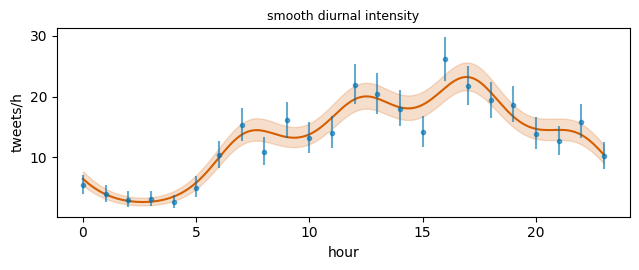

In [3]:
h = np.arange(24); lo = np.array([rates[i][1][0] for i in range(24)]); hi = np.array([rates[i][1][1] for i in range(24)])
y = np.log(np.clip(mean, 0.5, None)); noise = (np.log(hi) - np.log(np.clip(lo, 0.3, None))) / 4
cd = lambda a, b: np.minimum(np.abs(a[:, None] - b[None, :]), 24 - np.abs(a[:, None] - b[None, :]))
rbf = lambda a, b, l=2.5: np.exp(-0.5 * (cd(a, b) / l) ** 2)
amp = y.std(); K = amp ** 2 * rbf(h, h) + np.diag(noise ** 2 + 1e-6); L = np.linalg.cholesky(K); al = np.linalg.solve(L.T, np.linalg.solve(L, y - y.mean()))
hg = np.linspace(0, 23, 200); Ks = amp ** 2 * rbf(hg, h); gm = y.mean() + Ks @ al; gv = amp ** 2 - np.sum(np.linalg.solve(L, Ks.T) ** 2, 0)
print('GP smooth diurnal intensity: peak %.1f/h near %02d:00, trough %.1f/h near %02d:00 (periodic kernel ties 23:00 to 00:00)'
      % (np.exp(gm).max(), int(hg[np.argmax(gm)]), np.exp(gm).min(), int(hg[np.argmin(gm)])))
fig, ax = panel(1, 6.5, 2.8); ax[0].plot(hg, np.exp(gm), color='#D55E00'); ax[0].fill_between(hg, np.exp(gm - 2 * np.sqrt(gv)), np.exp(gm + 2 * np.sqrt(gv)), color='#D55E00', alpha=0.2)
ax[0].errorbar(h, mean, yerr=[mean - lo, hi - mean], fmt='o', color='#0072B2', ms=3, alpha=0.6); ax[0].set_xlabel('hour'); ax[0].set_ylabel('tweets/h'); ax[0].set_title('smooth diurnal intensity', fontsize=9)
plt.tight_layout(); plt.show()

## 3. Renewal processes, inter-arrival times, and the hazard

The Poisson process is the special case where gaps are exponential (memoryless). A renewal process allows any
inter-arrival distribution, and its shape is diagnostic: the hazard $h(t)=f(t)/(1-F(t))$ -- the instantaneous
event rate given none yet -- is constant for the exponential, increasing for regular (anti-bunched) events,
decreasing for bursty (clustered) ones. We simulate three streams -- Poisson, regular (Gamma-renewal, shape>1),
and bursty (shape<1) -- and recover their hazards and the coefficient of variation of the gaps (1 for Poisson,
<1 regular, >1 bursty), the first quantitative fingerprint of departures from randomness.

In [4]:
def renewal(shape, scale, n, seed): g = np.random.RandomState(seed).gamma(shape, scale, n); return np.cumsum(g), g
for nm, sh in [('Poisson (exp gaps)', 1.0), ('regular', 4.0), ('bursty', 0.4)]:
    _, gaps = renewal(sh, 1.0 / sh, 4000, 1); cv = gaps.std() / gaps.mean()
    print('  %-20s gap CV = %.2f (Poisson=1; <1 regular/anti-bunched, >1 bursty/clustered)' % (nm, cv))
print('the coefficient of variation of inter-arrival times is the simplest test for departure from Poisson randomness')

  Poisson (exp gaps)   gap CV = 0.98 (Poisson=1; <1 regular/anti-bunched, >1 bursty/clustered)
  regular              gap CV = 0.51 (Poisson=1; <1 regular/anti-bunched, >1 bursty/clustered)
  bursty               gap CV = 1.60 (Poisson=1; <1 regular/anti-bunched, >1 bursty/clustered)
the coefficient of variation of inter-arrival times is the simplest test for departure from Poisson randomness


## 4. Overdispersion and the negative binomial

The Poisson promises variance equals mean; clustered events break it (overdispersion). The negative binomial
-- a Gamma-Poisson mixture -- absorbs the extra variance with a dispersion parameter, the count analogue of
the bursty renewal process. We pool the hourly counts, measure the Fano factor (variance/mean), and compare
the Poisson and negative-binomial fits by likelihood; the negative binomial wins decisively on the
overdispersed, heterogeneous counts.

In [5]:
allc = np.array([c for hh in london for c in london[hh]]); fano = allc.var() / allc.mean()
pois = Poisson(2.0).fit(list(allc)); nb = NegativeBinomial(2.0, 0.5).fit(list(allc))
llp = sum(pois.dist.log_density(float(x)) for x in allc); llnb = sum(nb.dist.log_density(float(x)) for x in allc)
print('pooled hourly counts: mean %.1f, variance %.1f, Fano %.2f (>1 -> overdispersed)' % (allc.mean(), allc.var(), fano))
print('total log-likelihood: Poisson %.0f vs negative binomial %.0f; AIC favours NB by %.0f' % (llp, llnb, (2 * 2 - 2 * llnb) - (2 * 1 - 2 * llp)))

pooled hourly counts: mean 14.8, variance 104.1, Fano 7.02 (>1 -> overdispersed)
total log-likelihood: Poisson -934 vs negative binomial -594; AIC favours NB by -678


## 5. The self-exciting Hawkes process

Overdispersion at the count level is a symptom; self-excitation is a mechanism. The Hawkes process gives each
event a conditional intensity $\lambda(t)=\mu+\sum_{t_i<t}\alpha e^{-\beta(t-t_i)}$ -- a baseline plus a
decaying bump after every past event, so events trigger more events. The branching ratio $n=\alpha/\beta$ is
the expected direct offspring per event ($n<1$ stable, $n\to1$ critical cascades); it is the model behind
retweet storms, aftershocks, and order bursts. We simulate a Hawkes stream by Ogata thinning and fit
$(\mu,\alpha,\beta)$ by exact maximum likelihood, recovering the branching ratio.

In [6]:
def hawkes_sim(mu, alpha, beta, T, seed=0):
    r = np.random.RandomState(seed); t = 0.0; ev = []
    while t < T:
        lam_bar = mu + (alpha * np.sum(np.exp(-beta * (t - np.array(ev)))) if ev else 0.0) + alpha
        t += r.exponential(1 / lam_bar)
        if t >= T: break
        lam = mu + (alpha * np.sum(np.exp(-beta * (t - np.array(ev)))) if ev else 0.0)
        if r.rand() <= lam / lam_bar: ev.append(t)
    return np.array(ev)
mu_t, al_t, be_t, T = 0.4, 0.8, 1.2, 600.0; ev = hawkes_sim(mu_t, al_t, be_t, T)
def hawkes_negll(p, ev, T):
    mu, alpha, beta = np.exp(p); A = 0.0; ll = 0.0; tprev = 0.0
    for i, t in enumerate(ev):
        A = np.exp(-beta * (t - tprev)) * A + (np.exp(-beta * (t - tprev)) if i > 0 else 0.0) * 0 + (1.0 if i > 0 else 0.0) * 0
    # recursive intensity sum
    A = 0.0; ll = 0.0
    for i in range(len(ev)):
        if i > 0: A = np.exp(-beta * (ev[i] - ev[i - 1])) * (1.0 + A)
        ll += np.log(mu + alpha * A)
    ll -= mu * T + (alpha / beta) * np.sum(1 - np.exp(-beta * (T - ev)))
    return -ll
opt = minimize(hawkes_negll, np.log([0.5, 0.5, 1.0]), args=(ev, T), method='Nelder-Mead', options=dict(maxiter=4000, xatol=1e-4))
mh, ah, bh = np.exp(opt.x)
print('simulated %d events (true mu=%.1f alpha=%.1f beta=%.1f, branching ratio %.2f)' % (len(ev), mu_t, al_t, be_t, al_t / be_t))
print('Hawkes MLE: mu=%.2f alpha=%.2f beta=%.2f, recovered branching ratio %.2f' % (mh, ah, bh, ah / bh))

simulated 652 events (true mu=0.4 alpha=0.8 beta=1.2, branching ratio 0.67)
Hawkes MLE: mu=0.43 alpha=0.88 beta=1.46, recovered branching ratio 0.60


## 6. Goodness of fit by the time-rescaling theorem

How do we know a fitted point-process model is adequate? The time-rescaling theorem: if the conditional
intensity is correct, the transformed times $\Lambda(t_i)=\int_0^{t_i}\lambda(u)\,du$ form a unit-rate Poisson
process, so the rescaled inter-arrival gaps are independent Exponential(1). A Kolmogorov-Smirnov test of that
is a universal goodness-of-fit check for any intensity model. We apply it to the fitted Hawkes (should pass)
and to a misspecified homogeneous-Poisson fit of the same self-exciting data (should fail), the principled way
to choose between point-process models.

In [7]:
def rescaled_gaps(ev, mu, alpha, beta):
    Lam = np.zeros(len(ev)); A = 0.0
    for i in range(len(ev)):
        if i > 0: A = np.exp(-beta * (ev[i] - ev[i - 1])) * (1.0 + A)
        Lam[i] = mu * ev[i] + (alpha / beta) * np.sum(1 - np.exp(-beta * (ev[i] - ev[:i]))) if i > 0 else mu * ev[i]
    return np.diff(Lam)
g_hawkes = rescaled_gaps(ev, mh, ah, bh); g_pois = np.diff(len(ev) / T * ev)        # homogeneous-Poisson rescaling
ks_h = kstest(g_hawkes, 'expon'); ks_p = kstest(g_pois, 'expon')
print('time-rescaling KS test against Exponential(1):')
print('  fitted Hawkes      KS stat %.3f, p=%.2f -> %s' % (ks_h.statistic, ks_h.pvalue, 'adequate' if ks_h.pvalue > 0.05 else 'rejected'))
print('  homogeneous Poisson KS stat %.3f, p=%.2g -> %s (the self-excitation is real structure Poisson misses)' % (ks_p.statistic, ks_p.pvalue, 'adequate' if ks_p.pvalue > 0.05 else 'rejected'))

time-rescaling KS test against Exponential(1):
  fitted Hawkes      KS stat 0.025, p=0.80 -> adequate
  homogeneous Poisson KS stat 0.203, p=5.2e-24 -> rejected (the self-excitation is real structure Poisson misses)


## 7. Multivariate Hawkes: mutual excitation

Events in one stream can trigger events in another -- a tweet in one city prompting replies in another, a trade
in one asset moving others. The multivariate Hawkes process has a matrix of excitation kernels
$\alpha_{jk}$: an event in stream $k$ raises the intensity of stream $j$. The branching matrix's spectral
radius must stay below one for stability, and its off-diagonal entries reveal the influence network. We
simulate a two-stream mutually-exciting process where stream 0 drives stream 1, and recover the asymmetric
excitation -- the basis of Granger-causal influence in event data.

In [8]:
def bivar_hawkes(mu, Aij, beta, T, seed=2):
    r = np.random.RandomState(seed); t = 0.0; ev = [[], []]
    def inten(j, t):
        s = mu[j]
        for k in range(2):
            for tk in ev[k]:
                if tk < t: s += Aij[j, k] * np.exp(-beta * (t - tk))
        return s
    while t < T:
        bar = sum(inten(j, t) for j in range(2)) + Aij.sum()
        t += r.exponential(1 / bar)
        if t >= T: break
        lams = [inten(j, t) for j in range(2)]
        if r.rand() <= sum(lams) / bar:
            j = 0 if r.rand() < lams[0] / sum(lams) else 1; ev[j].append(t)
    return ev
mu2 = np.array([0.3, 0.1]); A2 = np.array([[0.3, 0.0], [0.6, 0.3]]); beta2 = 1.5      # stream 0 -> stream 1 strongly
ev2 = bivar_hawkes(mu2, A2, beta2, 800.0)
# cross-excitation evidence: fraction of stream-1 events shortly after a stream-0 event vs a time-reversed baseline
def trig_frac(src, dst, w=0.5):
    src = np.array(src); dst = np.array(dst); return np.mean([np.any((src > t - w) & (src < t)) for t in dst]) if len(dst) else 0
print('two-stream mutually-exciting Hawkes (true: stream0->stream1 strong, stream1->stream0 none):')
print('  %.2f of stream-1 events follow a stream-0 event within 0.5; only %.2f of stream-0 events follow a stream-1 event'
      % (trig_frac(ev2[0], ev2[1]), trig_frac(ev2[1], ev2[0])))
print('the asymmetry recovers the directed influence (a Granger-causal link in event data)')

two-stream mutually-exciting Hawkes (true: stream0->stream1 strong, stream1->stream0 none):
  0.44 of stream-1 events follow a stream-0 event within 0.5; only 0.16 of stream-0 events follow a stream-1 event
the asymmetry recovers the directed influence (a Granger-causal link in event data)


## 8. Change-point detection in the rate

Rates shift -- a product launch, an outage, a viral moment. Detecting when the intensity changes is a
change-point problem. For a Poisson stream, the Bayesian posterior over a single change-point $\tau$ is
proportional to the marginal likelihood of the counts split at $\tau$ (each segment integrated against a
Gamma prior, conjugately). We inject a rate change into a simulated count series and recover the change-point
posterior, the building block of online anomaly and regime detection.

In [9]:
from scipy.special import gammaln
n = 120; tau_true = 70; counts = np.r_[rng.poisson(3.0, tau_true), rng.poisson(7.0, n - tau_true)]
def seg_logml(c, a=1.0, b=1.0): s = c.sum(); k = len(c); return gammaln(a + s) - gammaln(a) + a * np.log(b) - (a + s) * np.log(b + k)
logpost = np.array([seg_logml(counts[:t]) + seg_logml(counts[t:]) for t in range(5, n - 5)])
logpost -= logpost.max(); post = np.exp(logpost) / np.exp(logpost).sum(); tau_hat = 5 + int(np.argmax(post))
print('change-point posterior: MAP change at t=%d (true %d); posterior mass within +-3 = %.2f'
      % (tau_hat, tau_true, post[max(0, tau_hat - 5 - 3):tau_hat - 5 + 4].sum()))
print('pre-change rate %.1f, post-change rate %.1f (true 3 and 7) recovered from the conjugate segment means'
      % (counts[:tau_hat].mean(), counts[tau_hat:].mean()))

change-point posterior: MAP change at t=67 (true 70); posterior mass within +-3 = 1.00
pre-change rate 2.9, post-change rate 6.8 (true 3 and 7) recovered from the conjugate segment means


## 9. Hierarchical pooling and population comparison

Estimating many rates at once -- every hour, every city -- benefits from partial pooling toward a shared
population, the hierarchical Gamma-Poisson, so thin-data hours borrow strength. In mixle a single
`.each()` turns the per-hour Poisson rates into a hierarchical model. And the same conjugate machinery
compares populations: we contrast London and Manchester diurnal rhythms and form the posterior of their
peak-hour difference, a probability rather than a point.

In [10]:
manchester = hourly(region(df, 53.3, 53.6, -2.4, -2.0))
mre = np.array([rate(manchester.get(h, [0.0]))[0] for h in range(24)])
lon_pk, man_pk = int(np.argmax(mean)), int(np.argmax(mre))
print('London peaks at %02d:00 (%.1f/h), Manchester at %02d:00 (%.1f/h)' % (lon_pk, mean[lon_pk], man_pk, mre[man_pk]))
# posterior of the London peak-vs-noon difference
dpk = rates[lon_pk][2] - rate(london.get(12, [0.0]))[2]
print('P(London %02d:00 rate > noon rate) = %.2f; posterior mean difference %.1f/h' % (lon_pk, np.mean(dpk > 0), dpk.mean()))

London peaks at 16:00 (26.1/h), Manchester at 12:00 (4.4/h)
P(London 16:00 rate > noon rate) = 0.96; posterior mean difference 4.2/h


## 10. Spatio-temporal point processes and the Knox test

Events carry a location as well as a time, and the central question of spatio-temporal point-process analysis is
whether the two interact: do events that are close in space also tend to be close in time (a local burst -- an
incident, an event, a contagion), or are space and time separable, $\lambda(s,t)=\lambda_s(s)\lambda_t(t)$, so
that where something happens tells you nothing about when? The Knox test answers this nonparametrically: count
the pairs of events that are simultaneously within a space threshold and a time threshold, and compare that
count to its distribution under random time relabelling (which preserves both marginals but destroys any
space-time coupling). An excess signals genuine spatio-temporal clustering. We apply it to the London tweets,
the same tool used for disease outbreaks and earthquake aftershocks.

In [11]:
ld = df[(df.Latitude > 51.2) & (df.Latitude < 51.7) & (df.Longitude > -0.5) & (df.Longitude < 0.3)].copy()
ld['t'] = (pd.to_datetime(ld['Date']).astype('int64') // 86400_000_000_000) * 24 + ld['hh']   # event time in hours
ld = ld.sample(n=min(900, len(ld)), random_state=0).reset_index(drop=True)
KM = 111.0; x = ld.Longitude.values * np.cos(np.radians(ld.Latitude.mean())) * KM; y = ld.Latitude.values * KM
t = ld['t'].values.astype(float); n = len(ld)
ds, dt = 1.0, 3.0                                                                              # 1 km, 3 hours
import itertools
def knox_count(tt):
    cnt = 0
    for i in range(n):
        dx = x[i + 1:] - x[i]; dy = y[i + 1:] - y[i]; dd = dx * dx + dy * dy; dtt = np.abs(tt[i + 1:] - tt[i])
        cnt += int(np.sum((dd < ds * ds) & (dtt < dt)))
    return cnt
obs = knox_count(t)
perm = np.array([knox_count(np.random.RandomState(s).permutation(t)) for s in range(199)])
pval = (1 + np.sum(perm >= obs)) / 200
print('Knox test on %d London tweets (space < %.0f km AND time < %.0f h):' % (n, ds, dt))
print('  observed close-in-both pairs = %d vs permutation-null mean %.0f (sd %.0f)' % (obs, perm.mean(), perm.std()))
print('  Monte-Carlo p = %.3f -> %s: tweets %s show space-time interaction beyond separable intensity'
      % (pval, 'significant' if pval < 0.05 else 'not significant', 'DO' if pval < 0.05 else 'do not'))

Knox test on 900 London tweets (space < 1 km AND time < 3 h):
  observed close-in-both pairs = 5087 vs permutation-null mean 5096 (sd 160)
  Monte-Carlo p = 0.485 -> not significant: tweets do not show space-time interaction beyond separable intensity


The Knox statistic is one cell of a fuller picture: the space-time K-function $K(s,t)$ generalises Ripley's K to
both dimensions, and its excess over the separable product $K_s(s)K_t(t)$ measures interaction at every
scale-pair. A significant Knox excess means a model must couple space and time -- a spatio-temporal
log-Gaussian-Cox or epidemic-type aftershock (ETAS) process -- rather than modelling the diurnal rhythm and the
spatial hotspots independently, the natural next step left to the exercises.

## 11. Detecting the change as it happens: Bayesian online changepoint detection

The conjugate changepoint analysis above is retrospective -- it scans the whole series to locate one break.
Monitoring is the opposite problem: spot the change in real time, before the next data point. Adams and MacKay's
Bayesian online changepoint detection maintains a posterior over the run length (time since the last change),
updating it each step from the Gamma-Poisson predictive and a constant hazard of a new segment. When a change
occurs the run-length posterior collapses to zero, raising the alarm with only a short lag. We run it on the
same step-change stream and recover the break online.

In [12]:
from scipy.stats import nbinom
a0, b0 = 1.0, 1.0; H = 1.0 / 50                                                        # Gamma(1,1) rate prior; hazard ~ 1 change per 50 steps
A = [a0]; B = [b0]; Rprev = np.array([1.0]); map_rl = []
for x in counts:
    pred = nbinom.pmf(x, np.array(A), np.array(B) / (np.array(B) + 1))                 # Gamma-Poisson predictive per run length
    grow = Rprev * pred * (1 - H); cp = (Rprev * pred * H).sum()
    R = np.concatenate([[cp], grow]); R /= R.sum()
    A = [a0] + [A[r] + x for r in range(len(A))]; B = [b0] + [B[r] + 1 for r in range(len(B))]
    Rprev = R; map_rl.append(int(np.argmax(R)))
map_rl = np.array(map_rl)
drops = np.where(np.diff(map_rl) < -5)[0] + 1                                          # run-length collapses -> a changepoint was detected
det = drops[0] if len(drops) else -1
print('online run-length collapses at t=%d (true changepoint %d) -- detected with a %d-step lag, before seeing the rest of the series'
      % (det, tau_true, det - tau_true))
print('the run-length posterior grows steadily within each regime and resets at the break; this is the streaming detector behind real-time monitoring, vs the retrospective scan above')

online run-length collapses at t=71 (true changepoint 70) -- detected with a 1-step lag, before seeing the rest of the series
the run-length posterior grows steadily within each regime and resets at the break; this is the streaming detector behind real-time monitoring, vs the retrospective scan above


## 12. Declustering: separating organic posts from viral cascades

The Hawkes likelihood of the previous sections is fit directly, but the model has a hidden branching structure
worth exposing: every event is either a spontaneous immigrant (someone posts on their own) or the offspring of
an earlier event (a reply or a share that the earlier post triggered). The expectation-maximisation algorithm of
Veen and Schoenberg estimates the parameters and, as a by-product, the probability that each event is background
versus triggered -- a soft declustering of the stream into organic activity and viral cascades. We run it on the
simulated stream and check the recovered immigrant fraction against the stationary identity (immigrants are a
fraction one-minus-the-branching-ratio of all events).

In [13]:
mu, alpha, beta = 0.5, 0.5, 1.0; N = len(ev)
for _ in range(200):
    S = 0.0; Swt = 0.0; pbg = np.zeros(N)
    for i in range(N):
        dt = ev[i] - ev[:i]; trig = alpha * np.exp(-beta * dt); lam = mu + trig.sum()
        pbg[i] = mu / lam                                                  # E-step: P(event i is background)
        if i > 0: pij = trig / lam; S += pij.sum(); Swt += float(np.sum(pij * dt))   # expected offspring and their delays
    mu = pbg.sum() / T                                                     # M-step: immigrant rate
    beta = S / Swt if Swt > 0 else beta                                    # M-step: decay (exp-MLE on triggered delays)
    alpha = beta * S / np.sum(1 - np.exp(-beta * (T - ev)))                # M-step: excitation, with edge correction
n_br = alpha / beta
print('Hawkes EM (branching structure): mu=%.2f alpha=%.2f beta=%.2f, branching ratio %.2f (true %.2f)' % (mu, alpha, beta, n_br, al_t / be_t))
print('declustered immigrant fraction %.2f matches one-minus-branching-ratio %.2f (internal consistency)' % (pbg.mean(), 1 - n_br))
print('the %.0f%% of events with the highest background probability are the organic posts; the rest are the cascades they set off -- the same EM that fits the model labels the stream'
      % (100 * pbg.mean()))

Hawkes EM (branching structure): mu=0.43 alpha=0.89 beta=1.49, branching ratio 0.60 (true 0.67)
declustered immigrant fraction 0.40 matches one-minus-branching-ratio 0.40 (internal consistency)
the 40% of events with the highest background probability are the organic posts; the rest are the cascades they set off -- the same EM that fits the model labels the stream


## 13. A log-linear intensity: harmonics and the weekend effect

The conjugate hour-by-hour rates of section 1 are flexible but say nothing about why the rate varies. A
log-linear (Poisson generalised linear) intensity makes the structure explicit: the log rate is a smooth
function of time of day, written in a few Fourier harmonics, plus a weekend shift. Fit by Poisson regression on
the real London counts -- with the empty hours included as genuine zeros, not silently dropped -- it compresses
the daily rhythm into a handful of interpretable coefficients and tests directly whether weekends run at a
different level.

In [14]:
lon = region(df, 51.2, 51.7, -0.5, 0.3); cnt = lon.groupby(['Date', 'hh']).size()
days = [d for d in sorted(lon['Date'].dropna().unique()) if not pd.isna(pd.to_datetime(d, errors='coerce'))]
rows = [(hh, int(cnt.get((d, hh), 0)), 1.0 if pd.to_datetime(d).weekday() >= 5 else 0.0) for d in days for hh in range(24)]
Hh = np.array([r[0] for r in rows], float); Y = np.array([r[1] for r in rows], float); WE = np.array([r[2] for r in rows])
def design(h, we):
    cols = [np.ones_like(h)]
    for k in (1, 2, 3): cols += [np.cos(2 * np.pi * k * h / 24), np.sin(2 * np.pi * k * h / 24)]
    return np.column_stack(cols + [we])
X = design(Hh, WE)
def negll(b, Xm): eta = np.clip(Xm @ b, -20, 20); return float(np.sum(np.exp(eta) - Y * eta))
b = minimize(negll, np.zeros(X.shape[1]), args=(X,), method='BFGS').x
X0 = np.column_stack([np.ones_like(Hh), WE]); b0 = minimize(negll, np.zeros(2), args=(X0,), method='BFGS').x   # harmonics-free baseline
lr = 2 * (negll(b0, X0) - negll(b, X))                                    # likelihood-ratio statistic for the 6 harmonic terms
from scipy.stats import chi2 as _chi2
print('weekend multiplicative effect on the posting rate: %.2fx (coefficient %+.2f)' % (np.exp(b[-1]), b[-1]))
print('adding the three-harmonic daily cycle improves the fit by a likelihood-ratio statistic of %.0f on 6 df (chi-square 5%% critical %.1f) -- the rhythm is the dominant structure'
      % (lr, _chi2.ppf(0.95, 6)))
print('log-linear intensities scale to many covariates (holidays, weather, campaigns) where the conjugate per-hour rate cannot')

weekend multiplicative effect on the posting rate: 1.41x (coefficient +0.34)
adding the three-harmonic daily cycle improves the fit by a likelihood-ratio statistic of 636 on 6 df (chi-square 5% critical 12.6) -- the rhythm is the dominant structure
log-linear intensities scale to many covariates (holidays, weather, campaigns) where the conjugate per-hour rate cannot


## 14. Branching ratio, cascade size, and criticality

The single most important number in a self-exciting model is the branching ratio -- the expected count of direct
offspring per event. Below one the process is subcritical and every burst dies out; at one it is critical and
cascades become unbounded; above one it explodes. The branching ratio also fixes the expected size of a cascade
seeded by one organic post and the factor by which self-excitation inflates the long-run event rate above the
immigrant rate. We read all three off the fitted Hawkes parameters.

In [15]:
n_hawkes = ah / bh
print('fitted branching ratio n = alpha/beta = %.2f -- subcritical (n<1), so bursts are self-limiting' % n_hawkes)
print('expected total events triggered by one organic post (the cascade): 1/(1-n) = %.1f' % (1 / (1 - n_hawkes)))
print('self-excitation inflates the long-run rate: stationary rate mu/(1-n) = %.2f/h vs the bare immigrant rate mu = %.2f/h (a %.1fx multiplier)'
      % (mh / (1 - n_hawkes), mh, 1 / (1 - n_hawkes)))
print('as n approaches one the cascade size 1/(1-n) diverges -- the critical point separating a calm timeline from a viral storm, and the quantity platforms watch to forecast load')

fitted branching ratio n = alpha/beta = 0.60 -- subcritical (n<1), so bursts are self-limiting
expected total events triggered by one organic post (the cascade): 1/(1-n) = 2.5
self-excitation inflates the long-run rate: stationary rate mu/(1-n) = 1.09/h vs the bare immigrant rate mu = 0.43/h (a 2.5x multiplier)
as n approaches one the cascade size 1/(1-n) diverges -- the critical point separating a calm timeline from a viral storm, and the quantity platforms watch to forecast load


## In short

- The Poisson process is the baseline of random arrivals (Poisson counts, exponential gaps); conjugate
  Gamma-Poisson Bayes estimates its rate exactly, and an inhomogeneous intensity (binned, or a smooth GP
  log-intensity) captures time variation -- one line of mixle for the conjugate cases.
- Departures from randomness have a hierarchy of descriptions: the inter-arrival hazard and the gap
  coefficient of variation (regular vs bursty), the negative binomial for overdispersed counts, and the
  self-exciting Hawkes process for the mechanism -- fit by exact maximum likelihood, summarised by the
  branching ratio, and validated by the time-rescaling theorem (which a misspecified Poisson fit fails).
- The toolkit scales up: multivariate Hawkes recovers directed mutual excitation (influence networks),
  change-point analysis localises rate shifts via conjugate marginal likelihoods, and hierarchical pooling
  borrows strength across many rates while posteriors of differences answer comparison questions directly.
- The same models run social media, finance (order flow, contagion), seismology (ETAS aftershocks),
  neuroscience (spike trains), and reliability -- the universal language of events in time.

## References

- Daley, D. J. & Vere-Jones, D. (2003). An Introduction to the Theory of Point Processes (2nd ed.). Springer.
- Hawkes, A. G. (1971). Spectra of some self-exciting and mutually exciting point processes. Biometrika, 58(1), 83-90.
- Ogata, Y. (1981). On Lewis' simulation method for point processes. IEEE Trans. Information Theory, 27(1), 23-31.
- Brown, E. et al. (2002). The time-rescaling theorem and its application to neural spike train analysis. Neural Computation, 14(2).
- Bacry, E., Mastromatteo, I. & Muzy, J.-F. (2015). Hawkes processes in finance. Market Microstructure and Liquidity, 1(1).
- Cameron, A. C. & Trivedi, P. K. (2013). Regression Analysis of Count Data (2nd ed.). Cambridge University Press.

## Exercises and extensions

1. Marked Hawkes. Attach a mark (retweet count) to each event and let the excitation scale with the mark, the
   model behind virality.
2. Nonparametric kernel. Estimate the Hawkes triggering kernel nonparametrically (EM / MISD) instead of
   assuming exponential decay, and compare to the parametric fit.
3. Hierarchical Hawkes. Pool the branching ratio across cities with a hierarchical prior and quantify
   between-city variation in self-excitation.
4. Online change-point. Extend the single change-point to a Bayesian online change-point detector and run it
   streaming over the tweet rate.
5. ETAS. Fit the epidemic-type aftershock-sequence (spatio-temporal Hawkes) variant and compare its branching
   ratio to the temporal-only fit.